In [1]:
from pathlib import Path
import torchaudio
from IPython.display import Audio
AUDIO_PATH = Path('../EMTD_dataset/processed/audio/000_NBMTc71yrpk.wav')

In [2]:
data, sample_rate = torchaudio.load(AUDIO_PATH)
print(f'sample rate: {sample_rate}')
print(f'data shape: {data.shape}')
print(f'time: {data.shape[1] / sample_rate} seconds')
# data is a tensor, convert to numpy for playback
Audio(data.numpy(), rate=sample_rate)

sample rate: 16000
data shape: torch.Size([2, 108000])
time: 6.75 seconds


torch.Size([1, 108000])
tensor([-6.1035e-05, -5.4932e-04, -1.2207e-04,  ...,  6.0181e-02,
         5.7404e-02,  3.4882e-02])
tensor([0.0000e+00, 6.2500e-05, 1.2500e-04,  ..., 6.7498e+00, 6.7499e+00,
        6.7499e+00])


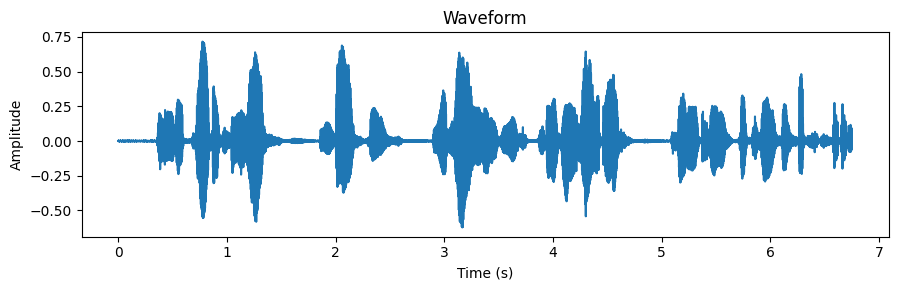

In [4]:
import torch
import matplotlib.pyplot as plt

if data.size(0) > 1:  # convert to mono if stereo
    wav = data.mean(dim=0, keepdim=True)
print(wav.shape)
x = wav[0]
print(x)
# Waveform
t = torch.arange(x.numel()) / sample_rate  # [time]
print(t)
plt.figure(figsize=(9,3))
plt.plot(t.numpy(), x.numpy())
plt.title("Waveform")
plt.xlabel("Time (s)"); 
plt.ylabel("Amplitude"); 
plt.tight_layout(); 
plt.show()

torch.Size([1025])


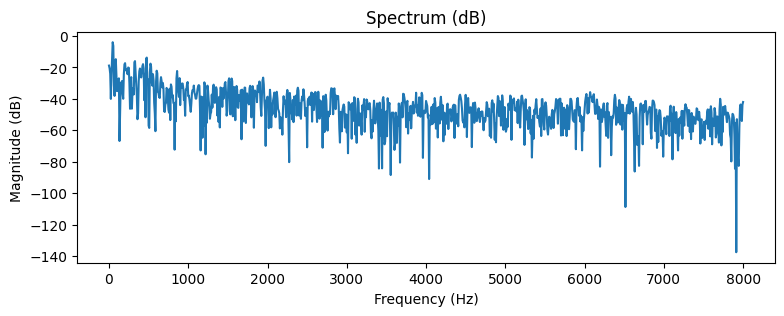

In [41]:
# Spectrum
spec = torchaudio.transforms.Spectrogram(n_fft=2048, power=1)(x)
mag_db = torchaudio.transforms.AmplitudeToDB(stype="magnitude")(spec)  # (freq_bins, frames)

# Take first column (first frame) as spectrum
spectrum = mag_db[:, 0]  # # (freq_bins,)
print(spectrum.shape)

freqs = torch.fft.rfftfreq(2048, 1 / sample_rate)
plt.figure(figsize=(9,3))
plt.plot(freqs.numpy(), spectrum.numpy())
plt.title("Spectrum (dB)"); plt.xlabel("Frequency (Hz)"); plt.ylabel("Magnitude (dB)")
plt.show()

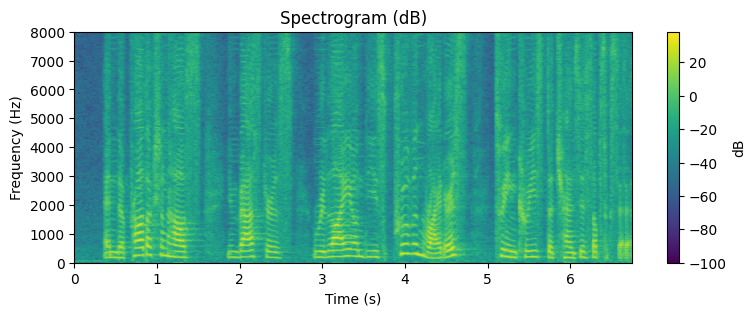

In [43]:
# Spectrogram (STFT via torchaudio)
spec = torchaudio.transforms.Spectrogram(n_fft=1024, hop_length=256)(x)
spec_db = torchaudio.transforms.AmplitudeToDB(stype="power")(spec)

plt.figure(figsize=(9,3))
plt.imshow(spec_db.numpy(), origin="lower", aspect="auto",
           extent=[0, x.numel()/sample_rate, 0, sample_rate/2])
plt.title("Spectrogram (dB)"); plt.xlabel("Time (s)"); plt.ylabel("Frequency (Hz)")
plt.colorbar(label="dB")
plt.show()

set hop length: 667
mel_db shape: torch.Size([80, 162])
dB range: [-41.52, 38.48]


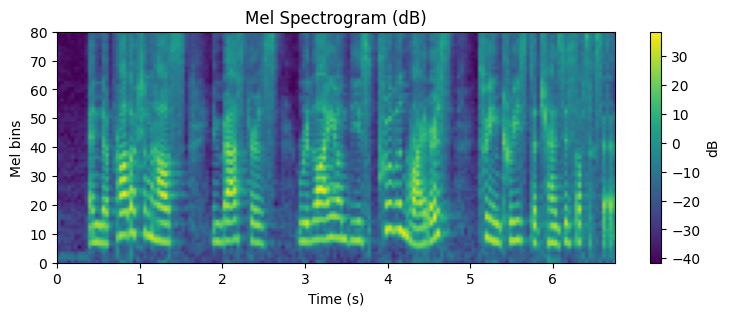

In [50]:
# Mel spectrogram
FPS = 24
hop_length = round(sample_rate / FPS)
print(f'set hop length: {hop_length}')
mel = torchaudio.transforms.MelSpectrogram(
    sample_rate=sample_rate, 
    n_fft=1024, 
    hop_length=hop_length, 
    n_mels=80,
    power=2.0   # This is the default
)(x)
mel_db = torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80.0)(mel)
print(f'mel_db shape: {mel_db.shape}')
print(f"dB range: [{mel_db.min().item():.2f}, {mel_db.max().item():.2f}]")

plt.figure(figsize=(9,3))
plt.imshow(mel_db.numpy(), origin="lower", aspect="auto",
           extent=[0, x.numel() / sample_rate, 0, 80])
plt.title("Mel Spectrogram (dB)"); plt.xlabel("Time (s)"); plt.ylabel("Mel bins")
plt.colorbar(label="dB")
plt.show()

dB range: [-46.11, 38.48]
